<a href="https://colab.research.google.com/github/beatag-1/cb2330-portfolio/blob/main/project_cb2330.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The data

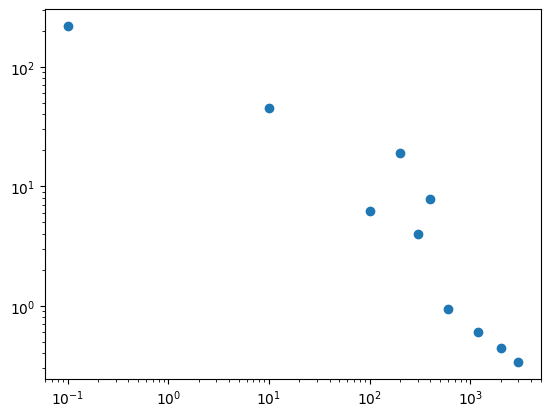

In [ ]:
depth = [0.1, 10, 100, 200, 300, 400, 600, 1200, 2000, 3000]
cell_density = [220, 45, 6.2, 19, 4, 7.8, 0.95, 0.61, 0.44, 0.34]


import matplotlib.pyplot as plt
import math
import numpy as np

plt.scatter(depth, cell_density)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
def function(x, c, k):
  return c*math.exp(-k*x)

def normal(x, mu, sigma):
  return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-((x - mu)**2) / (2 * sigma**2))

def nll_normal(depth, cell_density, c, k, sigma):
  total = 0.0
  for d, x in zip(depth, cell_density):
    mu = function (d,c,k)
    val = normal(x, mu, sigma)
    total = total-math.log(max(val, 1e-15))
  return total

def scoring(depth, cell_density):

  c_hat = 0.0
  k_hat = 0.0
  sigma_hat = 0.0

  best = float("inf")


  for i in range(200):
    c = 50 + 1 * i
    for j in range(100):
      sigma = 0.2 + 0.5 * j
      for l in range(100):
        k = 0.05 + 0.01 * l
        score = nll_normal(depth, cell_density, c, k, sigma)

        if score < best:
          best = score
          c_hat = c
          k_hat = k
          sigma_hat = sigma
  return c_hat, k_hat, sigma_hat, best


In [ ]:
c_hat, k_hat, sigma_hat, best= scoring(depth, cell_density)
print(c_hat, k_hat, sigma_hat)

In [ ]:
plt.plot(depth, [function(x, c_hat, k_hat) for x in depth])
plt.scatter(depth, cell_density)
plt.show()

In [ ]:
residuals = []
for i in range(len(cell_density)):
  residuals.append(cell_density[i] - function(depth[i], c_hat, k_hat))

In [ ]:
plt.scatter(depth, residuals)
plt.show()

In [ ]:
def forward_model(depth, c, k, sigma):

  mean = [function(x, c, k) for x in depth]

  simulations = np.zeros((1000, len(depth)))

  for i in range(1000):
    noise = np.random.normal(loc=0, scale= sigma, size=len(depth))
    simulations[i, :] = mean + noise


  return simulations


In [ ]:
np.random.seed(5)

simulation = forward_model(depth, c_hat, k_hat, sigma_hat)
print(simulation)

In [ ]:
plt.hist(simulation[:,0])
plt.show()



In [ ]:
plt.hist(simulation[:, -1])
plt.show()

In [ ]:
h = 0.01
c_curvature = (nll_normal(depth, cell_density, c_hat + h, k_hat, sigma_hat) - 2*nll_normal(depth, cell_density, c_hat, k_hat, sigma_hat) + nll_normal(depth, cell_density, c_hat - h, k_hat, sigma_hat))/h**2
se_c = 1/((c_curvature)**(0.5))

In [ ]:
print(c_curvature, se_c)

In [ ]:
h = 0.01
k_curvature = (nll_normal(depth, cell_density, c_hat, k_hat + h, sigma_hat) - 2*nll_normal(depth, cell_density, c_hat, k_hat, sigma_hat) + nll_normal(depth, cell_density, c_hat , k_hat - h, sigma_hat))/h**2
se_k = 1/((k_curvature)**(0.5))

print(k_curvature, se_k)

In [ ]:
h = 0.01
sigma_curvature = (nll_normal(depth, cell_density, c_hat, k_hat, sigma_hat + h) - 2*nll_normal(depth, cell_density, c_hat, k_hat, sigma_hat) + nll_normal(depth, cell_density, c_hat , k_hat, sigma_hat- h))/h**2
se_sigma = 1/((sigma_curvature)**(0.5))

print(sigma_curvature, se_sigma)

In [ ]:
near_c = (np.linspace(200, 240, 100)).tolist()

near_k = (np.linspace(0.005, 0.3, 100)).tolist()
near_sigma = (np.linspace(5, 16, 100)).tolist()

plt.plot(near_c, [nll_normal(depth, cell_density, c, k_hat, sigma_hat) for c in near_c])
plt.show()


In [ ]:
plt.plot(near_k, [nll_normal(depth, cell_density, c_hat, k, sigma_hat) for k in near_k])
plt.show()


In [ ]:
plt.plot(near_sigma, [nll_normal(depth, cell_density, c_hat, k_hat, sigma) for sigma in near_sigma])
plt.show()

In [ ]:
np.random.seed(5)

bootstrap_c = []
bootstrap_k = []
bootstrap_sigma = []

for i in range(1000):
  picked_indices = np.random.choice(len(depth), size = len(depth), replace = True)

boot_depth = depth[picked_indices]
boot_cell_density = cell_density[picked_indices]

c, k, sigma = scoring(boot_depth, boot_cell_density)


In [ ]:
lower = np.percentile(simulation, 2.5, axis = 0)
upper = np.percentile(simulation, 97.5, axis = 0)

plt.scatter(depth, cell_density, color = 'red')

plt.scatter(depth, [function(x, c_hat, k_hat) for x in depth], color = 'blue')

plt.fill_between(depth, lower, upper)

plt.xscale('log')
#plt.yscale('log')
plt.show()